In [ ]:
# Problem 1

import numpy as np
from scipy.stats import chisquare

obs = np.array([269,112,74,45])
exp = np.array([250,100,100,50])

# Pearson chi-square
chi2 = ((obs-exp)**2/exp).sum()

# Likelihood ratio
G2 = 2*np.sum(obs*np.log(obs/exp))

chi2, G2

(np.float64(10.144), np.float64(10.748373783444867))

In [ ]:
# Problem 2

from scipy.stats import chi2_contingency

table = np.array([
    [14,37,32],
    [19,42,17],
    [12,17,10]
])

chi2, p, dof, expected = chi2_contingency(table, lambda_="pearson")
G2, p_g, _, _ = chi2_contingency(table, lambda_="log-likelihood")

chi2, p, G2, p_g, expected

(np.float64(7.464393282240946),
 np.float64(0.11328968684800918),
 np.float64(7.400651680088086),
 np.float64(0.11617077106869157),
 array([[18.675, 39.84 , 24.485],
        [17.55 , 37.44 , 23.01 ],
        [ 8.775, 18.72 , 11.505]]))

In [ ]:
# Problem 3

table = np.array([
    [162,118,451,18],
    [310,196,996,25],
    [258,193,48,10],
    [280,175,390,19]
])

chi2, p, dof, expected = chi2_contingency(table)
G2, p_g, _, _ = chi2_contingency(table, lambda_="log-likelihood")

chi2, p, G2, p_g

(np.float64(527.1748258908709),
 np.float64(8.685927067306819e-108),
 np.float64(578.0839521941386),
 np.float64(1.055981104716337e-118))

In [ ]:
# Problem 4

table = np.array([
    [65,66,40,34],
    [42,30,33,42],
    [93,54,27,24]
])

chi2, p, dof, expected = chi2_contingency(table)
G2, p_g, _, _ = chi2_contingency(table, lambda_="log-likelihood")

chi2, p, G2, p_g

(np.float64(31.09936535589846),
 np.float64(2.426558231840781e-05),
 np.float64(30.322518932548725),
 np.float64(3.4129402618589284e-05))

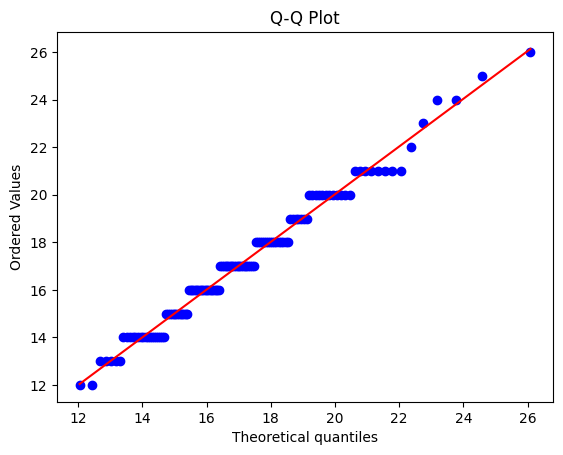

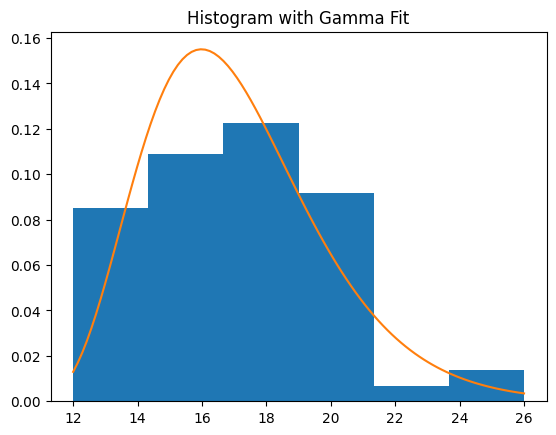

(np.float64(14.361895710329154),
 np.float64(14.947840241913987),
 np.float64(6.253378290493506),
 np.float64(1.1049478323911617))

In [ ]:
# Problem 5

import scipy.stats as stats
import matplotlib.pyplot as plt

# Load data
data = np.loadtxt('assemblytimes.txt')

# Histogram bins (6 classes)
counts, bins = np.histogram(data, bins=6)

# Fit gamma
alpha, loc, beta = stats.gamma.fit(data)

# Expected frequencies
cdf_vals = stats.gamma.cdf(bins, alpha, loc=loc, scale=beta)
expected = len(data) * np.diff(cdf_vals)

# Normalize (important)
expected *= counts.sum() / expected.sum()

# Chi-square
chi2 = np.sum((counts - expected)**2 / expected)

# Likelihood ratio
G2 = 2*np.sum(counts * np.log(counts / expected))

# QQ plot
stats.probplot(data, dist="gamma", sparams=(alpha, loc, beta), plot=plt)
plt.title("Q-Q Plot")
plt.show()

# Histogram + PDF
x = np.linspace(min(data), max(data), 100)
pdf = stats.gamma.pdf(x, alpha, loc=loc, scale=beta)

plt.hist(data, bins=6, density=True)
plt.plot(x, pdf)
plt.title("Histogram with Gamma Fit")
plt.show()

chi2, G2, alpha, beta